In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Dataset Overview

In this section, we load the housing dataset and check its shape, columns, data types, and missing values.

In [6]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             10 non-null     int64 
 1   area              10 non-null     int64 
 2   bedrooms          10 non-null     int64 
 3   bathrooms         10 non-null     int64 
 4   stories           10 non-null     int64 
 5   mainroad          10 non-null     object
 6   guestroom         10 non-null     object
 7   basement          10 non-null     object
 8   hotwaterheating   10 non-null     object
 9   airconditioning   10 non-null     object
 10  parking           10 non-null     int64 
 11  prefarea          10 non-null     object
 12  furnishingstatus  10 non-null     object
dtypes: int64(6), object(7)
memory usage: 1.1+ KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Day 2: Exploratory Data Analysis

In this section, we explore the housing dataset using summary statistics and visualizations.

In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,1.000000e+01,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1.122450e+07,8739.000000,3.800000,2.300000,2.600000,1.900000
std,1.235571e+06,2850.413031,0.632456,0.948683,1.074968,0.875595
min,9.800000e+06,5750.000000,3.000000,1.000000,1.000000,0.000000
25%,1.015000e+07,7440.000000,3.250000,2.000000,2.000000,2.000000
50%,1.113000e+07,7800.000000,4.000000,2.000000,2.000000,2.000000
75%,1.224125e+07,8865.000000,4.000000,3.000000,3.750000,2.000000
max,1.330000e+07,16200.000000,5.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

### Price Distribution

This graph shows how house prices are distributed in the dataset.

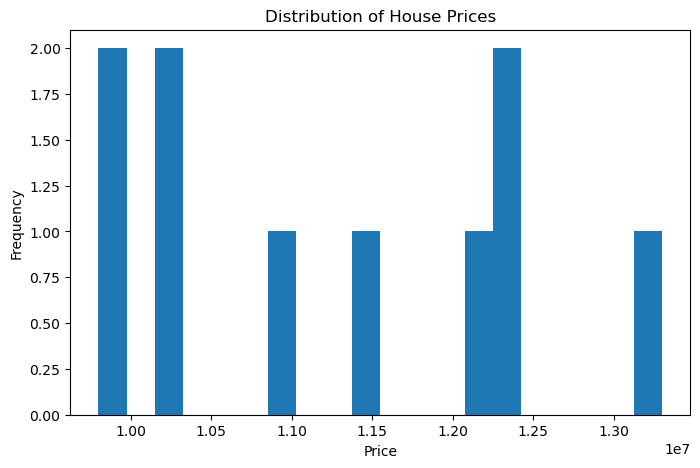

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

### Area vs Price

This scatter plot shows the relationship between house area and price.

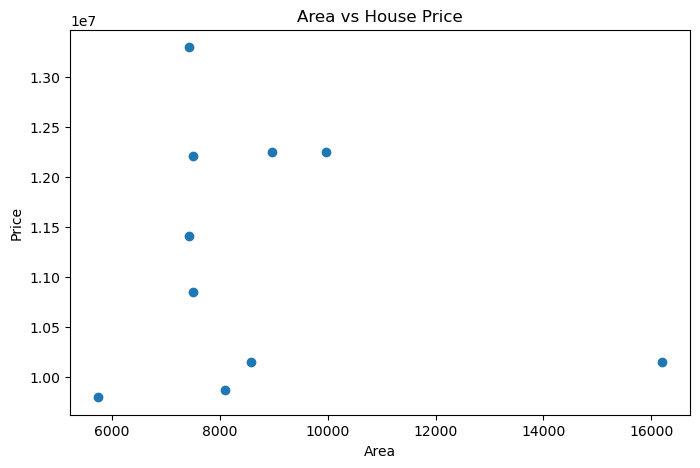

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs House Price")
plt.show()

### Bedroom Count

This chart shows how many houses have each number of bedrooms.

In [10]:
df["bedrooms"].value_counts()

bedrooms
4    6
3    3
5    1
Name: count, dtype: int64

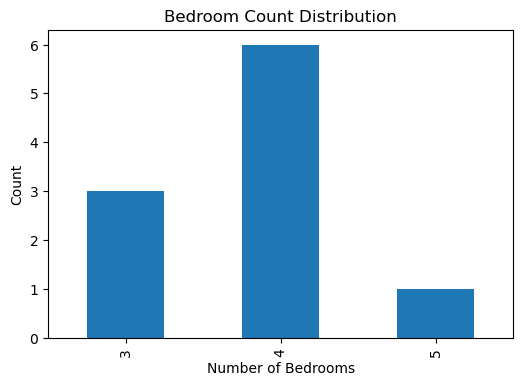

In [11]:
plt.figure(figsize=(6,4))
df["bedrooms"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.title("Bedroom Count Distribution")
plt.show()

### Average Price by Number of Bedrooms

This shows how the average house price changes with the number of bedrooms.

In [12]:
avg_price_bedrooms = df.groupby("bedrooms")["price"].mean()
avg_price_bedrooms

bedrooms
3    1.096667e+07
4    1.153250e+07
5    1.015000e+07
Name: price, dtype: float64

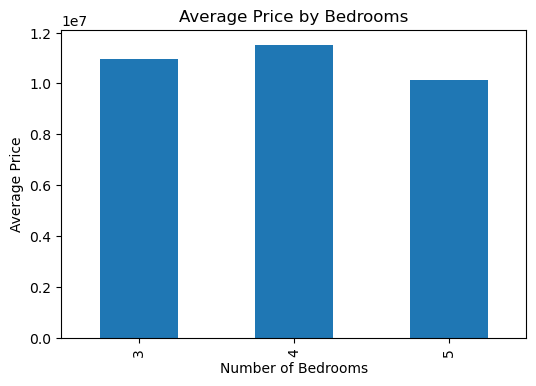

In [13]:
plt.figure(figsize=(6,4))
avg_price_bedrooms.plot(kind="bar")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.title("Average Price by Bedrooms")
plt.show()

### Furnishing Status Analysis

This shows the number of houses by furnishing status.

In [14]:
df["furnishingstatus"].value_counts()

furnishingstatus
furnished         5
semi-furnished    3
unfurnished       2
Name: count, dtype: int64

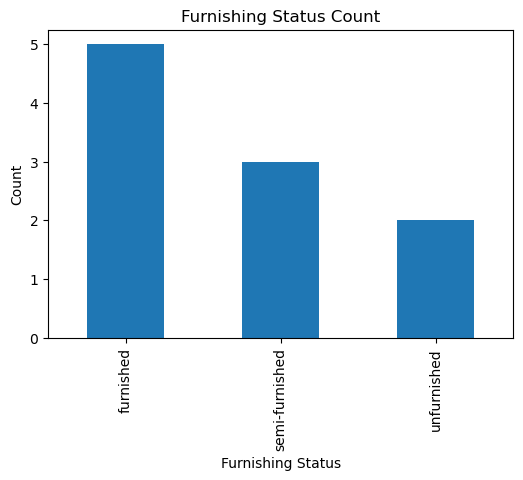

In [15]:
plt.figure(figsize=(6,4))
df["furnishingstatus"].value_counts().plot(kind="bar")
plt.xlabel("Furnishing Status")
plt.ylabel("Count")
plt.title("Furnishing Status Count")
plt.show()

In [16]:
avg_price_furnishing = df.groupby("furnishingstatus")["price"].mean()
avg_price_furnishing

furnishingstatus
furnished         1.180900e+07
semi-furnished    1.108333e+07
unfurnished       9.975000e+06
Name: price, dtype: float64

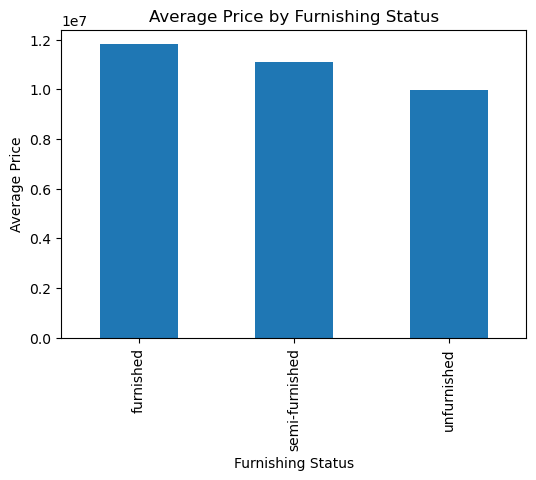

In [17]:
plt.figure(figsize=(6,4))
avg_price_furnishing.plot(kind="bar")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")
plt.title("Average Price by Furnishing Status")
plt.show()

### Correlation Analysis

Correlation helps us understand how strongly numeric features are related to house price.

In [18]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,-0.157408,-0.042798,0.066022,-0.041577,0.574063
area,-0.157408,1.000000,0.645184,0.347739,-0.215180,-0.576567
bedrooms,-0.042798,0.645184,1.000000,0.111111,0.032686,-0.240772
bathrooms,0.066022,0.347739,0.111111,1.000000,0.348651,0.040129
stories,-0.041577,-0.215180,0.032686,0.348651,1.000000,0.070829
parking,0.574063,-0.576567,-0.240772,0.040129,0.070829,1.000000


In [19]:
numeric_df.corr()["price"].sort_values(ascending=False)

price        1.000000
parking      0.574063
bathrooms    0.066022
stories     -0.041577
bedrooms    -0.042798
area        -0.157408
Name: price, dtype: float64

## EDA Observations

- The dataset contains housing features such as area, bedrooms, bathrooms, parking, and furnishing status.
- The target variable is price.
- Area appears to have a positive relationship with price.
- Furnishing status may affect house price.
- Bedroom count also influences average price.
- No missing values were found in the dataset.

## Day 3: Data Preparation

In this section, we prepare the housing dataset so it can be used by machine learning models.

In [20]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [21]:
X = df.drop("price", axis=1)
y = df["price"]

In [24]:
X.head()
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [25]:
X.dtypes

area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [26]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()
X_encoded.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'guestroom_yes',
       'basement_yes', 'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [27]:
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (10, 12)
Encoded X shape: (10, 11)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8, 11)
X_test shape: (2, 11)
y_train shape: (8,)
y_test shape: (2,)


## Day 3 Notes

- The price column was separated as the output.
- All remaining columns were used as input.
- Text-based columns were converted into numeric columns.
- The data was divided into training and testing parts.
- The dataset is now ready for model training.